In [1]:
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
import seaborn as sns
import os
import glob
from datetime import datetime
from datetime import timedelta
from matplotlib import pyplot as plt
import matplotlib.dates as md
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
from matplotlib import cm
import matplotlib.dates as mdates
from scipy.interpolate import interp2d
warnings.filterwarnings('ignore')
#import datetime
import scipy.ndimage as ndimage
from matplotlib import cm
import geopy.distance
#import matplotlib as mpl
from scipy.interpolate import interp1d
from sklearn.linear_model import LinearRegression
from shapely.geometry import Point
import geopandas as gpd
from geopandas import GeoDataFrame
import leafmap
import plotly.express as px
import matplotlib as mpl
import xarray as xr
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D
import math
#import pysplit
import netCDF4
import xarray as xr

In [2]:
# Directory containing the Excel files
excel_dirTropHC = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/HCHO_Tropomi' # Replace with the directory containing your .xlsx files

# List to store DataFrames
dataframes = []

# Loop through all files in the directory
for file in os.listdir(excel_dirTropHC):
    if file.endswith(".xlsx"):  # Ensure it's an Excel file
        file_path = os.path.join(excel_dirTropHC, file)
        print(f"Reading file: {file_path}")
        df = pd.read_excel(file_path)  # Read the Excel file
        dataframes.append(df)  # Append the DataFrame to the list

# Combine all DataFrames into one (since all share the same column names)
combined_HC = pd.concat(dataframes, ignore_index=True)

# Analyze the combined DataFrame
print("\nCombined DataFrame (First 5 Rows):")
print(combined_HC.head())  # Display the first few rows



Reading file: C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/HCHO_Tropomi\Childrens_Park.xlsx
Reading file: C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/HCHO_Tropomi\Coach_Line.xlsx
Reading file: C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/HCHO_Tropomi\Craycroft.xlsx
Reading file: C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/HCHO_Tropomi\Fairgrounds.xlsx
Reading file: C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/HCHO_Tropomi\Green_Valley.xlsx
Reading file: C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/HCHO_Tropomi\Rose_Elementary.xlsx
Reading file: C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/HCHO_Tropomi\Saguaro_Park.xlsx
Reading file: C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/HCHO_Tropomi\Tangerine.xlsx

Combined DataFrame (First 5 Rows):
        Date Variable      Value
0 2019-01-01     CH2O   3.72868

In [3]:
combined_HC

,Date,Variable,Value
0,2019-01-01,CH2O,3.728688
1,2019-01-02,CH2O,13.089196
2,2019-01-03,CH2O,13.257077
3,2019-01-04,CH2O,1.431932
4,2019-01-07,CH2O,6.637563
...,...,...,...
7186,2022-12-03,CH2O,5.516699
7187,2022-12-10,CH2O,16.283722
7188,2022-12-17,CH2O,2.728163
7189,2022-12-24,CH2O,17.389541


In [4]:
import os

# Directory containing the Excel files
excel_dirTrop = 'C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NOx_Tropomi' # Replace with the directory containing your .xlsx files

# List to store DataFrames
dataframes = []

# Loop through all files in the directory
for file in os.listdir(excel_dirTrop):
    if file.endswith(".xlsx"):  # Ensure it's an Excel file
        file_path = os.path.join(excel_dirTrop, file)
        print(f"Reading file: {file_path}")
        df = pd.read_excel(file_path)  # Read the Excel file
        dataframes.append(df)  # Append the DataFrame to the list

# Combine all DataFrames into one (since all share the same column names)
combined_Trop = pd.concat(dataframes, ignore_index=True)

# Analyze the combined DataFrame
print("\nCombined DataFrame (First 5 Rows):")
print(combined_Trop.head())  # Display the first few rows



Reading file: C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NOx_Tropomi\Childrens_Park.xlsx
Reading file: C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NOx_Tropomi\Coach_Line.xlsx
Reading file: C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NOx_Tropomi\Craycroft.xlsx
Reading file: C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NOx_Tropomi\Fairgrounds.xlsx
Reading file: C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NOx_Tropomi\Green_Valley.xlsx
Reading file: C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NOx_Tropomi\Rose_Elementary.xlsx
Reading file: C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NOx_Tropomi\Saguaro_Park.xlsx
Reading file: C:/Users/taiwoajayi/\OneDrive - University of Arizona/Arizona_ozone/NOx_Tropomi\Tangerine.xlsx

Combined DataFrame (First 5 Rows):
        Date Variable     Value
0 2019-01-01      NO2  1.990669
1 2019-0

In [5]:
from scipy.stats import kendalltau

# Define seasons
seasons = ['Fall/Winter', 'Spring', 'Dry Summer', 'Monsoon Summer']

# Aggregate data for each season
def seasonal_aggregation(df, season):
    df['Month'] = pd.to_datetime(df['Date']).dt.month
    if season == 'Fall/Winter':
        season_df = df[df['Month'].isin([9, 10, 11, 12, 1, 2])]
    elif season == 'Spring':
        season_df = df[df['Month'].isin([3, 4, 5])]
    elif season == 'Dry Summer':
        season_df = df[df['Month'] == 6]
    elif season == 'Monsoon Summer':
        season_df = df[df['Month'].isin([7, 8])]
    return season_df

# Mann-Kendall trend test for VOC and NO2 datasets
def mann_kendall_voc_no2(data, label):
    data['Year'] = pd.to_datetime(data['Date']).dt.year
    trend_results = {}
    for season in seasons:
        season_df = seasonal_aggregation(data, season)
        if not season_df.empty:
            median_by_year = season_df.groupby('Year')['Value'].mean()
            all_years = median_by_year.index
            all_medians = median_by_year.values
            tau, p_value = kendalltau(all_years, all_medians)
            significance = 'Significant' if p_value < 0.05 else 'Not Significant'
            trend_results[season] = {'Label': label, 'Kendall tau': tau, 'p-value': p_value, 'Significance': significance}
    return pd.DataFrame.from_dict(trend_results, orient='index')

# Main Execution for VOC and NO2
voc_trend_df = mann_kendall_voc_no2(combined_HC, 'VOC')
no2_trend_df = mann_kendall_voc_no2(combined_Trop, 'NO2')

print("Mann-Kendall trend test results for VOC:")
print(voc_trend_df)
print("\nMann-Kendall trend test results for NO2:")
print(no2_trend_df)


Mann-Kendall trend test results for VOC:
               Label  Kendall tau   p-value     Significance
Fall/Winter      VOC    -0.800000  0.083333  Not Significant
Spring           VOC    -0.333333  0.750000  Not Significant
Dry Summer       VOC     0.000000  1.000000  Not Significant
Monsoon Summer   VOC    -0.666667  0.333333  Not Significant

Mann-Kendall trend test results for NO2:
               Label  Kendall tau  p-value     Significance
Fall/Winter      NO2     0.000000     1.00  Not Significant
Spring           NO2     0.333333     0.75  Not Significant
Dry Summer       NO2     0.000000     1.00  Not Significant
Monsoon Summer   NO2     0.333333     0.75  Not Significant


In [6]:
# Step 1: Convert 'Date' column to datetime
combined_HC['Date'] = pd.to_datetime(combined_HC['Date'])
combined_Trop['Date'] = pd.to_datetime(combined_Trop['Date'])

# Step 2: Extract 'Year' and 'YearMonth' for grouping
combined_HC['Year'] = combined_HC['Date'].dt.year.astype(int)
combined_HC['YearMonth'] = combined_HC['Date'].dt.to_period('M')

combined_Trop['Year'] = combined_Trop['Date'].dt.year.astype(int)
combined_Trop['YearMonth'] = combined_Trop['Date'].dt.to_period('M')

# Step 3: Define boolean masks separately for each DataFrame
def create_masks(df):
    return {
        '2019': df['Year'] == 2019,
        '2020': df['Year'] == 2020,
        '2021': df['Year'] == 2021,
        '2022': df['Year'] == 2022,
    }

VOC_masks = create_masks(combined_HC)
NOx_masks = create_masks(combined_Trop)

# Step 4: Apply masks correctly (ensuring alignment)
VOC_binned = {period: combined_HC.loc[mask].copy() for period, mask in VOC_masks.items()}
NOx_binned = {period: combined_Trop.loc[mask].copy() for period, mask in NOx_masks.items()}

# Step 5: Compute Monthly Aggregates for VOC and NOx
VOC_monthly = {}
NOx_monthly = {}
FNR_monthly = {}

for period in VOC_binned.keys():
    # Aggregate by YearMonth
    VOC_monthly[period] = VOC_binned[period].groupby('YearMonth')['Value'].agg(
        average='mean',
        percentile_25=lambda x: x.quantile(0.25),
        percentile_75=lambda x: x.quantile(0.75)
    ).reset_index()

    NOx_monthly[period] = NOx_binned[period].groupby('YearMonth')['Value'].agg(
        average='median',
        percentile_25=lambda x: x.quantile(0.25),
        percentile_75=lambda x: x.quantile(0.75)
    ).reset_index()

    # Compute FNR (VOC / NOx) for each YearMonth
    FNR_monthly[period] = VOC_monthly[period][['average', 'percentile_25', 'percentile_75']].div(
        NOx_monthly[period][['average', 'percentile_25', 'percentile_75']].values
    )

    # Add 'YearMonth' column back to FNR DataFrame
    FNR_monthly[period]['YearMonth'] = VOC_monthly[period]['YearMonth']

    # Reorder columns
    FNR_monthly[period] = FNR_monthly[period][['YearMonth', 'average', 'percentile_25', 'percentile_75']]

# Step 6: Convert results to DataFrames for easy analysis
VOC_stats_df = pd.concat(VOC_monthly.values(), keys=VOC_monthly.keys()).reset_index().rename(columns={'level_0': 'Period'}).drop(columns=['level_1'])
NOx_stats_df = pd.concat(NOx_monthly.values(), keys=NOx_monthly.keys()).reset_index().rename(columns={'level_0': 'Period'}).drop(columns=['level_1'])
FNR_stats_df = pd.concat(FNR_monthly.values(), keys=FNR_monthly.keys()).reset_index().rename(columns={'level_0': 'Period'}).drop(columns=['level_1'])

# Display results
print("VOC Monthly Data:\n", VOC_stats_df)
print("\nNOx Monthly Data:\n", NOx_stats_df)
print("\nFNR Monthly Data:\n", FNR_stats_df)


VOC Monthly Data:
    Period YearMonth    average  percentile_25  percentile_75
0    2019   2019-01   7.687463       4.165690       9.162092
1    2019   2019-02   6.645084       3.658779       9.040605
2    2019   2019-03   7.183423       3.573145       9.221292
3    2019   2019-04   7.297087       4.301934       9.312093
4    2019   2019-05   7.898671       4.412320      10.234097
5    2019   2019-06  10.190744       5.316723      14.004396
6    2019   2019-07  11.924733       7.518921      14.931369
7    2019   2019-08  11.370388       7.757143      14.227882
8    2019   2019-09  10.065933       5.638764      13.344727
9    2019   2019-10   9.332952       4.667423      12.742013
10   2019   2019-11  10.006968       4.850477      12.925341
11   2019   2019-12   8.623360       4.296494      11.192189
12   2020   2020-01   8.175003       3.549582      10.567484
13   2020   2020-02   9.054748       4.423655      12.338810
14   2020   2020-03   8.045709       3.994104      11.287346
15   

In [7]:
# Step 1: Convert 'Date' to datetime format
combined_HC['Date'] = pd.to_datetime(combined_HC['Date'])
combined_Trop['Date'] = pd.to_datetime(combined_Trop['Date'])

# Step 2: Extract 'Year' and 'Month' for grouping
combined_HC['Year'] = combined_HC['Date'].dt.year.astype(int)
combined_HC['Month'] = combined_HC['Date'].dt.month

combined_Trop['Year'] = combined_Trop['Date'].dt.year.astype(int)
combined_Trop['Month'] = combined_Trop['Date'].dt.month

# Step 3: Define boolean masks separately for each DataFrame
def create_masks(df):
    return {
        '2019': df['Year'] == 2019,
        '2020': df['Year'] == 2020,
        '2021': df['Year'] == 2021,
        '2022': df['Year'] == 2022,
    }

VOC_masks = create_masks(combined_HC)
NOx_masks = create_masks(combined_Trop)

# Step 4: Apply masks correctly (ensuring alignment)
VOC_binned = {period: combined_HC.loc[mask].copy() for period, mask in VOC_masks.items()}
NOx_binned = {period: combined_Trop.loc[mask].copy() for period, mask in NOx_masks.items()}

# Step 5: Compute Monthly Aggregates for VOC and NOx (Ensuring 12 Data Points per Period)
VOC_monthly = {}
NOx_monthly = {}
FNR_monthly = {}

for period in VOC_binned.keys():
    # Aggregate over all years in the period, grouping only by Month (1-12)
    VOC_monthly[period] = VOC_binned[period].groupby('Month')['Value'].agg(
        average='mean',
        percentile_25=lambda x: x.quantile(0.25),
        percentile_75=lambda x: x.quantile(0.75)
    ).reset_index()

    NOx_monthly[period] = NOx_binned[period].groupby('Month')['Value'].agg(
        average='median',  # Using median for NOx
        percentile_25=lambda x: x.quantile(0.25),
        percentile_75=lambda x: x.quantile(0.75)
    ).reset_index()

    # Compute FNR (VOC / NOx) for each Month (Ensuring Exactly 12 Points)
    FNR_monthly[period] = VOC_monthly[period][['average', 'percentile_25', 'percentile_75']].div(
        NOx_monthly[period][['average', 'percentile_25', 'percentile_75']].values
    )

    # Add 'Month' column back to FNR DataFrame
    FNR_monthly[period]['Month'] = VOC_monthly[period]['Month']

    # Reorder columns
    FNR_monthly[period] = FNR_monthly[period][['Month', 'average', 'percentile_25', 'percentile_75']]

# Step 6: Convert results to DataFrames for easy analysis
VOC_stats_df = pd.concat(VOC_monthly.values(), keys=VOC_monthly.keys()).reset_index().rename(columns={'level_0': 'Period'}).drop(columns=['level_1'])
NOx_stats_df = pd.concat(NOx_monthly.values(), keys=NOx_monthly.keys()).reset_index().rename(columns={'level_0': 'Period'}).drop(columns=['level_1'])
FNR_stats_df = pd.concat(FNR_monthly.values(), keys=FNR_monthly.keys()).reset_index().rename(columns={'level_0': 'Period'}).drop(columns=['level_1'])

# Display results
print("VOC Monthly Data:\n", VOC_stats_df)
print("\nNOx Monthly Data:\n", NOx_stats_df)
print("\nFNR Monthly Data:\n", FNR_stats_df)


VOC Monthly Data:
    Period  Month    average  percentile_25  percentile_75
0    2019      1   7.687463       4.165690       9.162092
1    2019      2   6.645084       3.658779       9.040605
2    2019      3   7.183423       3.573145       9.221292
3    2019      4   7.297087       4.301934       9.312093
4    2019      5   7.898671       4.412320      10.234097
5    2019      6  10.190744       5.316723      14.004396
6    2019      7  11.924733       7.518921      14.931369
7    2019      8  11.370388       7.757143      14.227882
8    2019      9  10.065933       5.638764      13.344727
9    2019     10   9.332952       4.667423      12.742013
10   2019     11  10.006968       4.850477      12.925341
11   2019     12   8.623360       4.296494      11.192189
12   2020      1   8.175003       3.549582      10.567484
13   2020      2   9.054748       4.423655      12.338810
14   2020      3   8.045709       3.994104      11.287346
15   2020      4   8.080790       3.733075      10.80

In [8]:
FNR_stats_df

,Period,Month,average,percentile_25,percentile_75
0,2019,1,3.091851,2.627200,2.651939
1,2019,2,3.224012,2.351812,2.912819
2,2019,3,3.625764,2.342701,3.161399
3,2019,4,4.195023,3.383328,3.783867
4,2019,5,4.531429,3.242958,4.436471
5,2019,6,6.322218,4.095006,6.536300
6,2019,7,5.653881,4.500236,5.652802
7,2019,8,5.864294,4.860090,5.699568
8,2019,9,5.535781,4.016907,5.666771
9,2019,10,5.595211,3.309767,5.454320


In [9]:
FNR_stats_dff = FNR_stats_df[FNR_stats_df['Period'] != '2019'].copy()
FNR_stats_dff

,Period,Month,average,percentile_25,percentile_75
12,2020,1,3.263780,1.981493,2.927059
13,2020,2,3.883302,2.531639,3.460446
14,2020,3,4.665382,2.934976,5.181698
15,2020,4,5.208121,2.890526,5.599010
16,2020,5,5.414755,3.880224,5.641778
17,2020,6,5.505277,4.288770,5.409467
18,2020,7,6.328395,4.794228,6.935845
19,2020,8,6.132908,4.489289,6.272097
20,2020,9,6.000543,3.673343,5.878585
21,2020,10,4.479334,3.254476,4.518606


In [10]:
"""import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Convert 'Date' to datetime
combined_HC['Date'] = pd.to_datetime(combined_HC['Date'])
combined_Trop['Date'] = pd.to_datetime(combined_Trop['Date'])

# Step 2: Extract Year and Month
for df in [combined_HC, combined_Trop]:
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month

# Step 3: Compute per-month anomaly summaries
def calc_yearly_anomaly_summary(df, value_col='Value', id='VOC'):
    summaries = {}
    for y1, y0 in [(2021, 2020), (2022, 2021)]:
        label = f"{id}_anomaly_{y1}_{y0}"
        df_y1 = df[df['Year'] == y1].copy()
        df_y0 = df[df['Year'] == y0].copy()

        merged = pd.merge(df_y1, df_y0, on='Month', suffixes=(f'_{y1}', f'_{y0}'))
        merged['anomaly'] = merged[f'{value_col}_{y1}'] - merged[f'{value_col}_{y0}']
        merged['Month'] = merged['Month'].astype(int)

        summary = merged.groupby('Month')['anomaly'].agg(
            median='median',
            percentile_25=lambda x: x.quantile(0.25),
            percentile_75=lambda x: x.quantile(0.75)
        ).reset_index()

        summaries[label] = summary
    return summaries

# Step 4: Apply to VOC and NOx
VOC_anomaly_summaries = calc_yearly_anomaly_summary(combined_HC, value_col='Value', id='VOC')
NOx_anomaly_summaries = calc_yearly_anomaly_summary(combined_Trop, value_col='Value', id='NOx')

# Step 5: Prepare FNR by merging first
def calc_FNR_anomaly_summary(voc_df, nox_df):
    merged = pd.merge(
        voc_df[['Date', 'Year', 'Month', 'Value']],
        nox_df[['Date', 'Year', 'Month', 'Value']],
        on='Date',
        suffixes=('_VOC', '_NOx')
    )
    merged['FNR_Value'] = merged['Value_VOC'] / merged['Value_NOx']
    merged['Year'] = pd.to_datetime(merged['Date']).dt.year
    merged['Month'] = pd.to_datetime(merged['Date']).dt.month
    return calc_yearly_anomaly_summary(merged, value_col='FNR_Value', id='FNR')

FNR_anomaly_summaries = calc_FNR_anomaly_summary(combined_HC, combined_Trop)

# Optional: Print example summary
print("VOC anomaly 2021-2020:\n", VOC_anomaly_summaries['VOC_anomaly_2021_2020'])
print("VOC anomaly 2022-2021:\n", VOC_anomaly_summaries['VOC_anomaly_2022_2021'])

print("NOx anomaly 2021-2020:\n", NOx_anomaly_summaries['NOx_anomaly_2021_2020'])
print("NOx anomaly 2022-2021:\n", NOx_anomaly_summaries['NOx_anomaly_2022_2021'])

print("FNR anomaly 2021-2020:\n", FNR_anomaly_summaries['FNR_anomaly_2021_2020'])
print("FNR anomaly 2022-2021:\n", FNR_anomaly_summaries['FNR_anomaly_2022_2021'])"""


'import pandas as pd\nimport seaborn as sns\nimport matplotlib.pyplot as plt\n\n# Step 1: Convert \'Date\' to datetime\ncombined_HC[\'Date\'] = pd.to_datetime(combined_HC[\'Date\'])\ncombined_Trop[\'Date\'] = pd.to_datetime(combined_Trop[\'Date\'])\n\n# Step 2: Extract Year and Month\nfor df in [combined_HC, combined_Trop]:\n    df[\'Year\'] = df[\'Date\'].dt.year\n    df[\'Month\'] = df[\'Date\'].dt.month\n\n# Step 3: Compute per-month anomaly summaries\ndef calc_yearly_anomaly_summary(df, value_col=\'Value\', id=\'VOC\'):\n    summaries = {}\n    for y1, y0 in [(2021, 2020), (2022, 2021)]:\n        label = f"{id}_anomaly_{y1}_{y0}"\n        df_y1 = df[df[\'Year\'] == y1].copy()\n        df_y0 = df[df[\'Year\'] == y0].copy()\n\n        merged = pd.merge(df_y1, df_y0, on=\'Month\', suffixes=(f\'_{y1}\', f\'_{y0}\'))\n        merged[\'anomaly\'] = merged[f\'{value_col}_{y1}\'] - merged[f\'{value_col}_{y0}\']\n        merged[\'Month\'] = merged[\'Month\'].astype(int)\n\n        summary =

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Convert 'Date' to datetime
combined_HC['Date'] = pd.to_datetime(combined_HC['Date'])
combined_Trop['Date'] = pd.to_datetime(combined_Trop['Date'])

# Step 2: Extract Year and Month
for df in [combined_HC, combined_Trop]:
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month

# Step 3: Compute per-month climatological median and anomalies
def calc_climatology_anomaly_summary(df, value_col='Value', id='VOC'):
    summaries = {}

    # Climatology: median per month across all years
    climatology = df.groupby('Month')[value_col].median().reset_index()
    climatology.rename(columns={value_col: 'Climatology_Median'}, inplace=True)

    # Unique years
    for year in sorted(df['Year'].unique()):
        df_year = df[df['Year'] == year].copy()
        merged = pd.merge(df_year, climatology, on='Month')
        merged['anomaly'] = merged[value_col] - merged['Climatology_Median']

        summary = merged.groupby('Month')['anomaly'].agg(
            median='median',
            percentile_25=lambda x: x.quantile(0.25),
            percentile_75=lambda x: x.quantile(0.75)
        ).reset_index()

        summaries[f"{id}_anomaly_{year}_climatology"] = summary

    return summaries

# Step 4: Apply to VOC and NOx
VOC_anomaly_summaries = calc_climatology_anomaly_summary(combined_HC, value_col='Value', id='VOC')
NOx_anomaly_summaries = calc_climatology_anomaly_summary(combined_Trop, value_col='Value', id='NOx')

# Step 5: Compute FNR anomalies

def calc_FNR_climatology_anomaly_summary(voc_df, nox_df):
    merged = pd.merge(
        voc_df[['Date', 'Year', 'Month', 'Value']],
        nox_df[['Date', 'Year', 'Month', 'Value']],
        on='Date',
        suffixes=('_VOC', '_NOx')
    )
    merged['FNR_Value'] = merged['Value_VOC'] / merged['Value_NOx']
    merged['Year'] = pd.to_datetime(merged['Date']).dt.year
    merged['Month'] = pd.to_datetime(merged['Date']).dt.month
    return calc_climatology_anomaly_summary(merged, value_col='FNR_Value', id='FNR')

FNR_anomaly_summaries = calc_FNR_climatology_anomaly_summary(combined_HC, combined_Trop)

# Optional: Print sample output
for year in sorted(combined_HC['Year'].unique()):
    print(f"VOC anomaly {year} vs climatology:\n", VOC_anomaly_summaries[f'VOC_anomaly_{year}_climatology'])
    print(f"NOx anomaly {year} vs climatology:\n", NOx_anomaly_summaries[f'NOx_anomaly_{year}_climatology'])
    print(f"FNR anomaly {year} vs climatology:\n", FNR_anomaly_summaries[f'FNR_anomaly_{year}_climatology'])


VOC anomaly 2019 vs climatology:
     Month    median  percentile_25  percentile_75
0       1  0.161751      -2.302866       2.693536
1       2 -0.256983      -2.524743       2.857083
2       3  0.084026      -2.785862       2.862285
3       4  0.137880      -1.652677       3.357482
4       5  0.098034      -2.181639       3.640138
5       6  0.798968      -3.350302       5.337371
6       7  1.266649      -2.606307       4.806142
7       8  1.195768      -1.617367       4.853371
8       9  1.197730      -2.624659       5.081304
9      10  1.478046      -2.616426       5.458164
10     11  1.395151      -2.902320       5.172543
11     12  0.356743      -2.467640       4.428055
NOx anomaly 2019 vs climatology:
     Month    median  percentile_25  percentile_75
0       1 -0.146167      -1.046929       0.822336
1       2 -0.268244      -0.773638       0.774364
2       3  0.031589      -0.424402       0.967212
3       4  0.066135      -0.401819       0.787671
4       5 -0.063720      -0.4462

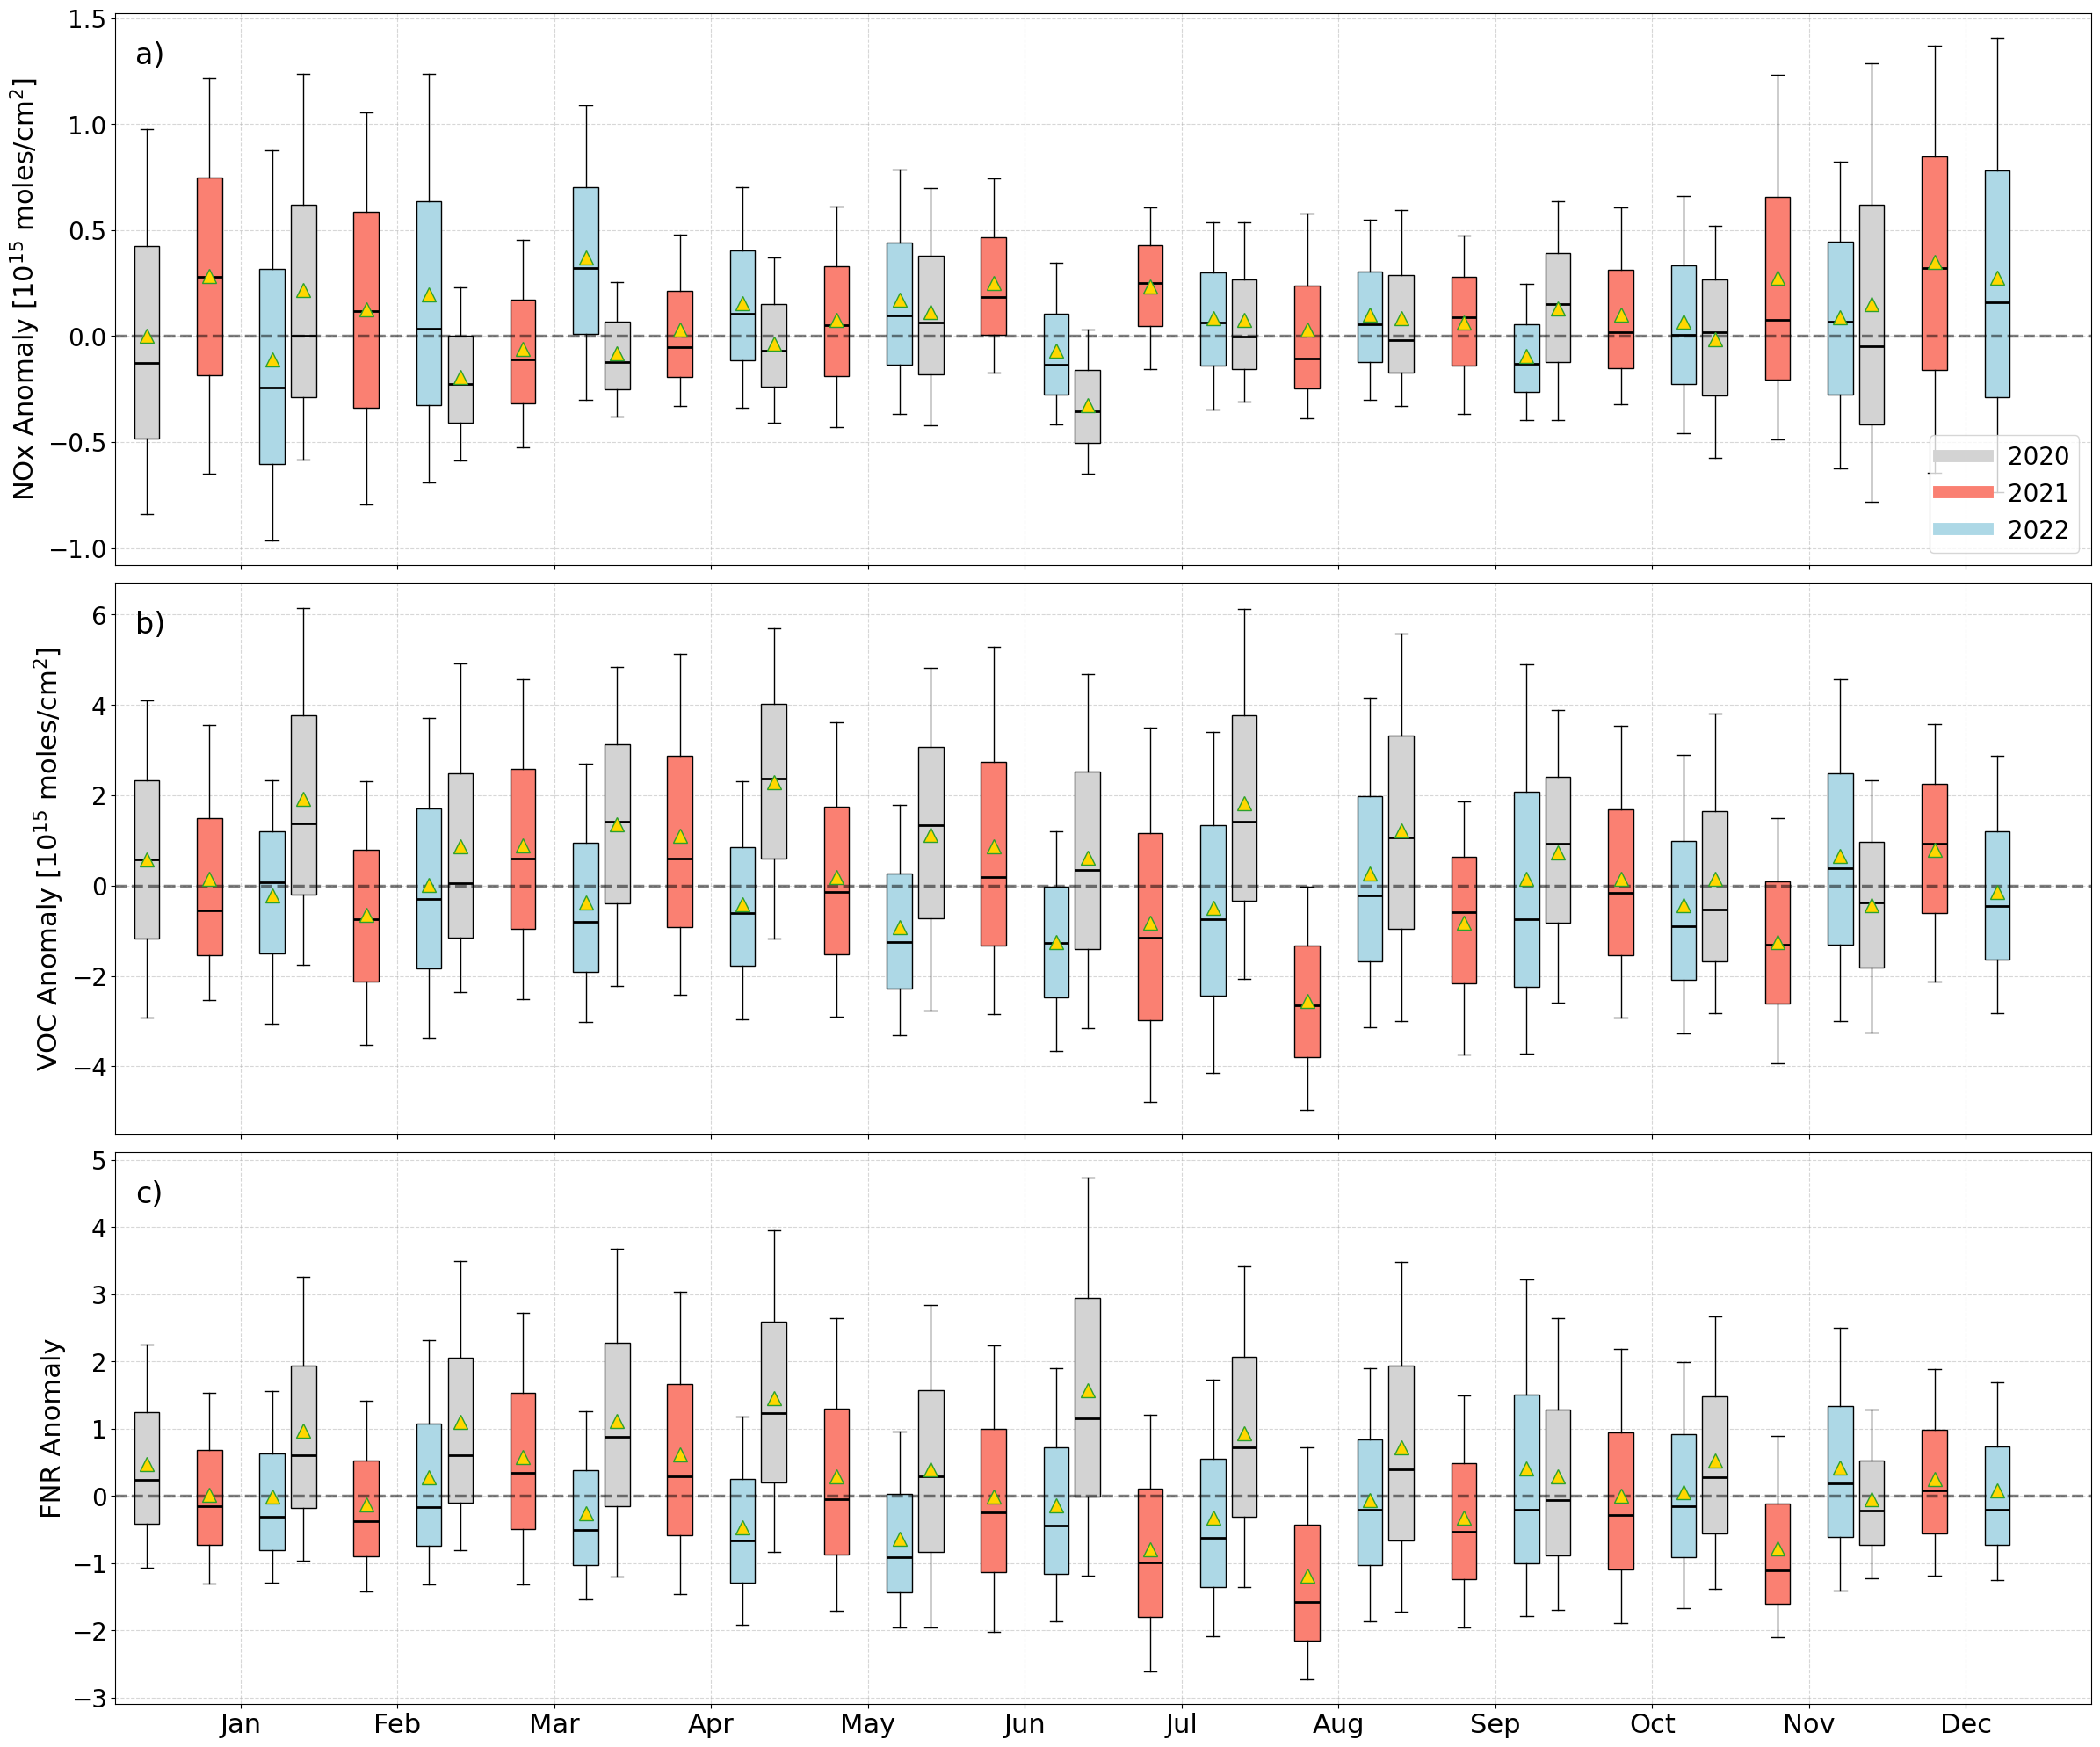

In [12]:
import calendar

def build_box_data(summary_df):
    # Ensure all 12 months are present and ordered
    summary_df = summary_df.set_index('Month').reindex(range(1, 13)).reset_index()
    summary_df.fillna(np.nan, inplace=True)
    return [
        [row['percentile_25'], row['median'], row['percentile_75']]
        if not pd.isnull(row['median']) else [np.nan, np.nan, np.nan]
        for _, row in summary_df.iterrows()
    ]

def plot_summary_boxplots(nox_sum, voc_sum, fnr_sum):
    years = [2020, 2021, 2022]
    months = [calendar.month_abbr[m] for m in range(1, 13)]
    x_base = np.arange(1, 13) * 5
    positions_per_year = {
        2020: x_base - 3,
        2021: x_base - 1,
        2022: x_base + 1,
    }
    colors = {
        2020: 'lightgray',
        2021: 'salmon',
        2022: 'lightblue',
    }

    fig, axes = plt.subplots(3, 1, figsize=(24, 20), sharex=True)

    def draw(ax, anomaly_summaries, key_prefix, ylabel, tag):
        for year in years:
            key = f"{key_prefix}_anomaly_{year}_climatology"
            if key in anomaly_summaries:
                data = build_box_data(anomaly_summaries[key])
                ax.boxplot(
                    data,
                    positions=positions_per_year[year],
                    widths=0.8,
                    patch_artist=True,
                    showmeans=True,
                    boxprops=dict(facecolor=colors[year], color='black'),
                    medianprops=dict(color='black', linewidth=2),
                    meanprops=dict(marker='^', markerfacecolor='gold', markersize=12)
                )

        ax.set_xticks(x_base)
        ax.set_xticklabels(months, fontsize=22)
        ax.set_xlim(x_base[0] - 4, x_base[-1] + 4)
        ax.axhline(y=0, color='k', linestyle='--', linewidth=2.5, alpha=0.5)
        ax.set_ylabel(ylabel, fontsize=22)
        ax.tick_params(axis='y', labelsize=20)
        ax.text(0.01, 0.95, tag, fontsize=24, transform=ax.transAxes, va='top')
        ax.grid(True, linestyle='--', alpha=0.5)

    draw(axes[0], nox_sum, 'NOx', 'NOx Anomaly [$10^{15}$ moles/cm$^2$]', 'a)')
    draw(axes[1], voc_sum, 'VOC', 'VOC Anomaly [$10^{15}$ moles/cm$^2$]', 'b)')
    draw(axes[2], fnr_sum, 'FNR', 'FNR Anomaly', 'c)')

    handles = [
        plt.Line2D([0], [0], color=colors[yr], lw=10, label=str(yr))
        for yr in years
    ]
    axes[0].legend(handles=handles, fontsize=20, loc='lower right')

    plt.tight_layout()
    plt.show()

# Call the function
plot_summary_boxplots(NOx_anomaly_summaries, VOC_anomaly_summaries, FNR_anomaly_summaries)


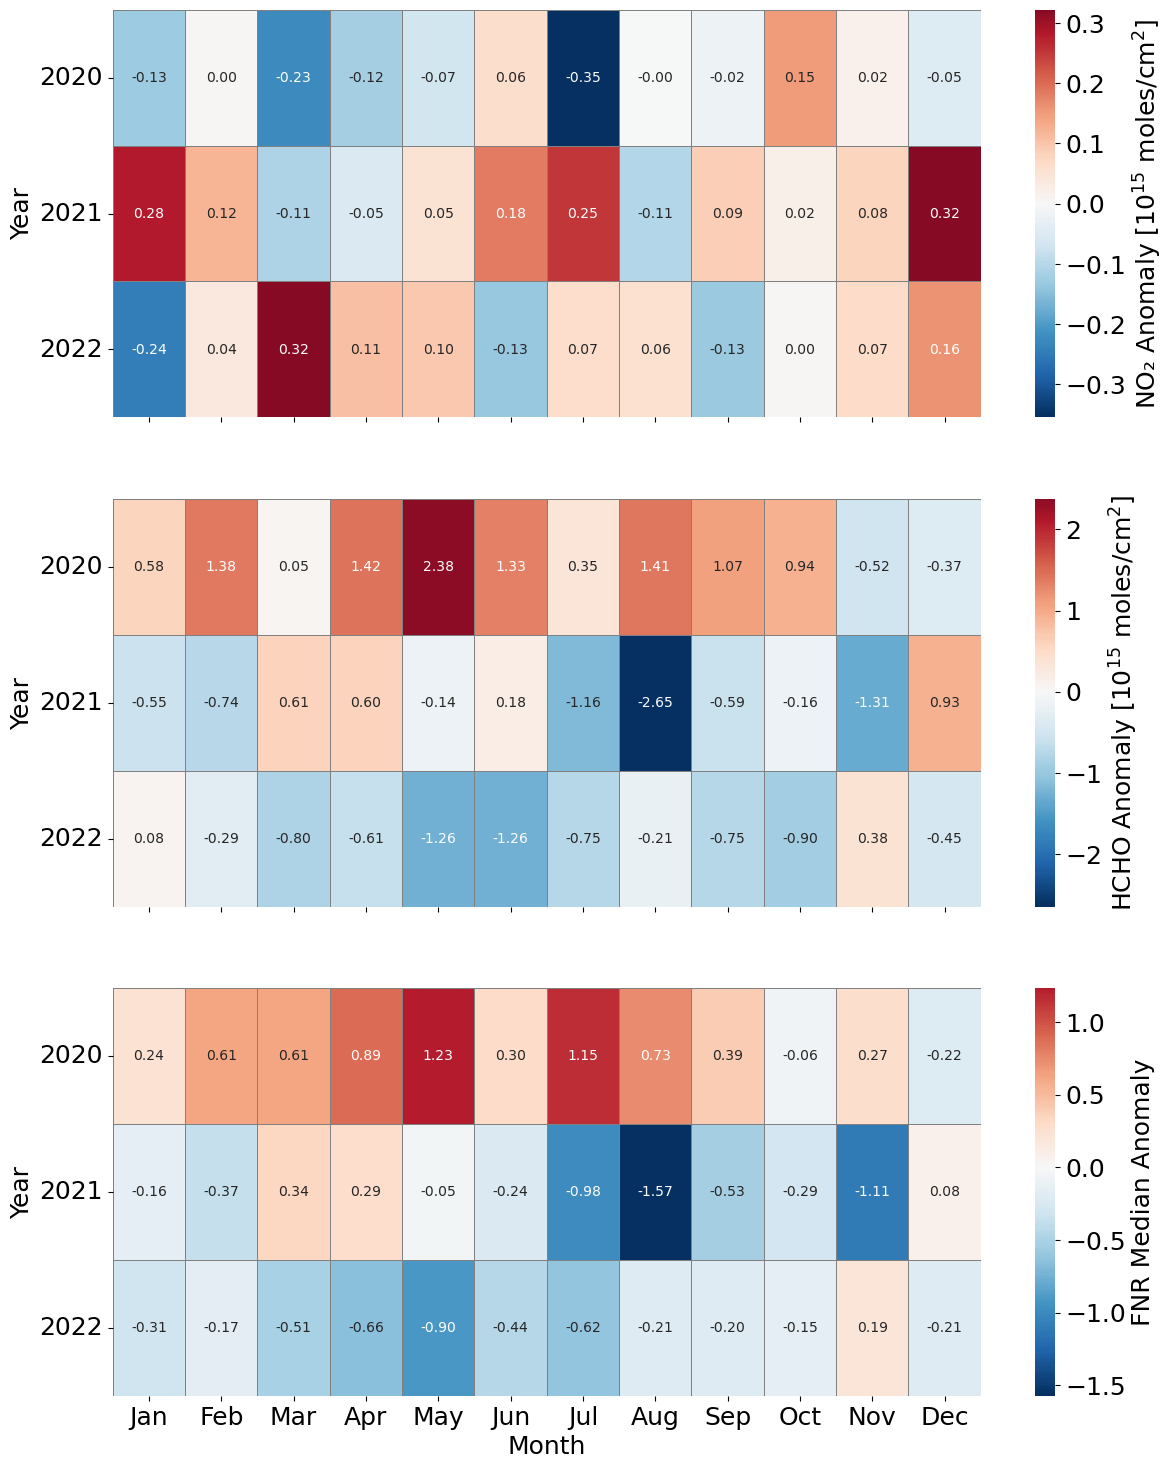

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import calendar

def build_anomaly_matrix(summaries, id):
    records = []
    for key, df in summaries.items():
        if key.startswith(f"{id}_anomaly_"):
            year = int(key.split('_')[2])
            if year in [2019, 2023]:
                continue
            for _, row in df.iterrows():
                records.append({
                    'Year': year,
                    'Month': int(row['Month']),
                    'Anomaly': row['median']
                })

    df_matrix = pd.DataFrame(records)
    pivot = df_matrix.pivot(index='Year', columns='Month', values='Anomaly')
    return pivot

def plot_combined_anomaly_heatmaps(nox_mat, voc_mat, fnr_mat):
    fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharex=True,
                             gridspec_kw={'hspace': 0.20})

    #fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharex=True)

    heatmaps = [
       (nox_mat, 'NO\u2082 Anomaly [$10^{15}$ moles/cm$^2$]'),  # NOₓ
        (voc_mat, 'HCHO Anomaly [$10^{15}$ moles/cm$^2$]'),
        (fnr_mat, "FNR Median Anomaly")
    ]

    for ax, (data, colorbar_label) in zip(axes, heatmaps):
        heatmap = sns.heatmap(data, ax=ax, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                    cbar_kws={'label': colorbar_label}, linewidths=0.5, linecolor='gray')
        cbar = heatmap.collections[0].colorbar
        cbar.ax.tick_params(labelsize=18)             # Tick label size
        cbar.set_label(colorbar_label, fontsize=18)
        ax.set_ylabel("Year", fontsize=18)
        ax.set_xlabel("")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
        ax.tick_params(axis='both', labelsize=18)
        ax.set_xticks(np.arange(12) + 0.5)
        ax.set_xticklabels([calendar.month_abbr[m] for m in range(1, 13)], fontsize=18)

    axes[-1].set_xlabel("Month", fontsize=18)
    plt.tight_layout()
    plt.show()

# Build matrices
voc_matrix = build_anomaly_matrix(VOC_anomaly_summaries, 'VOC')
nox_matrix = build_anomaly_matrix(NOx_anomaly_summaries, 'NOx')
fnr_matrix = build_anomaly_matrix(FNR_anomaly_summaries, 'FNR')

# Plot heatmaps
plot_combined_anomaly_heatmaps(nox_matrix, voc_matrix, fnr_matrix)


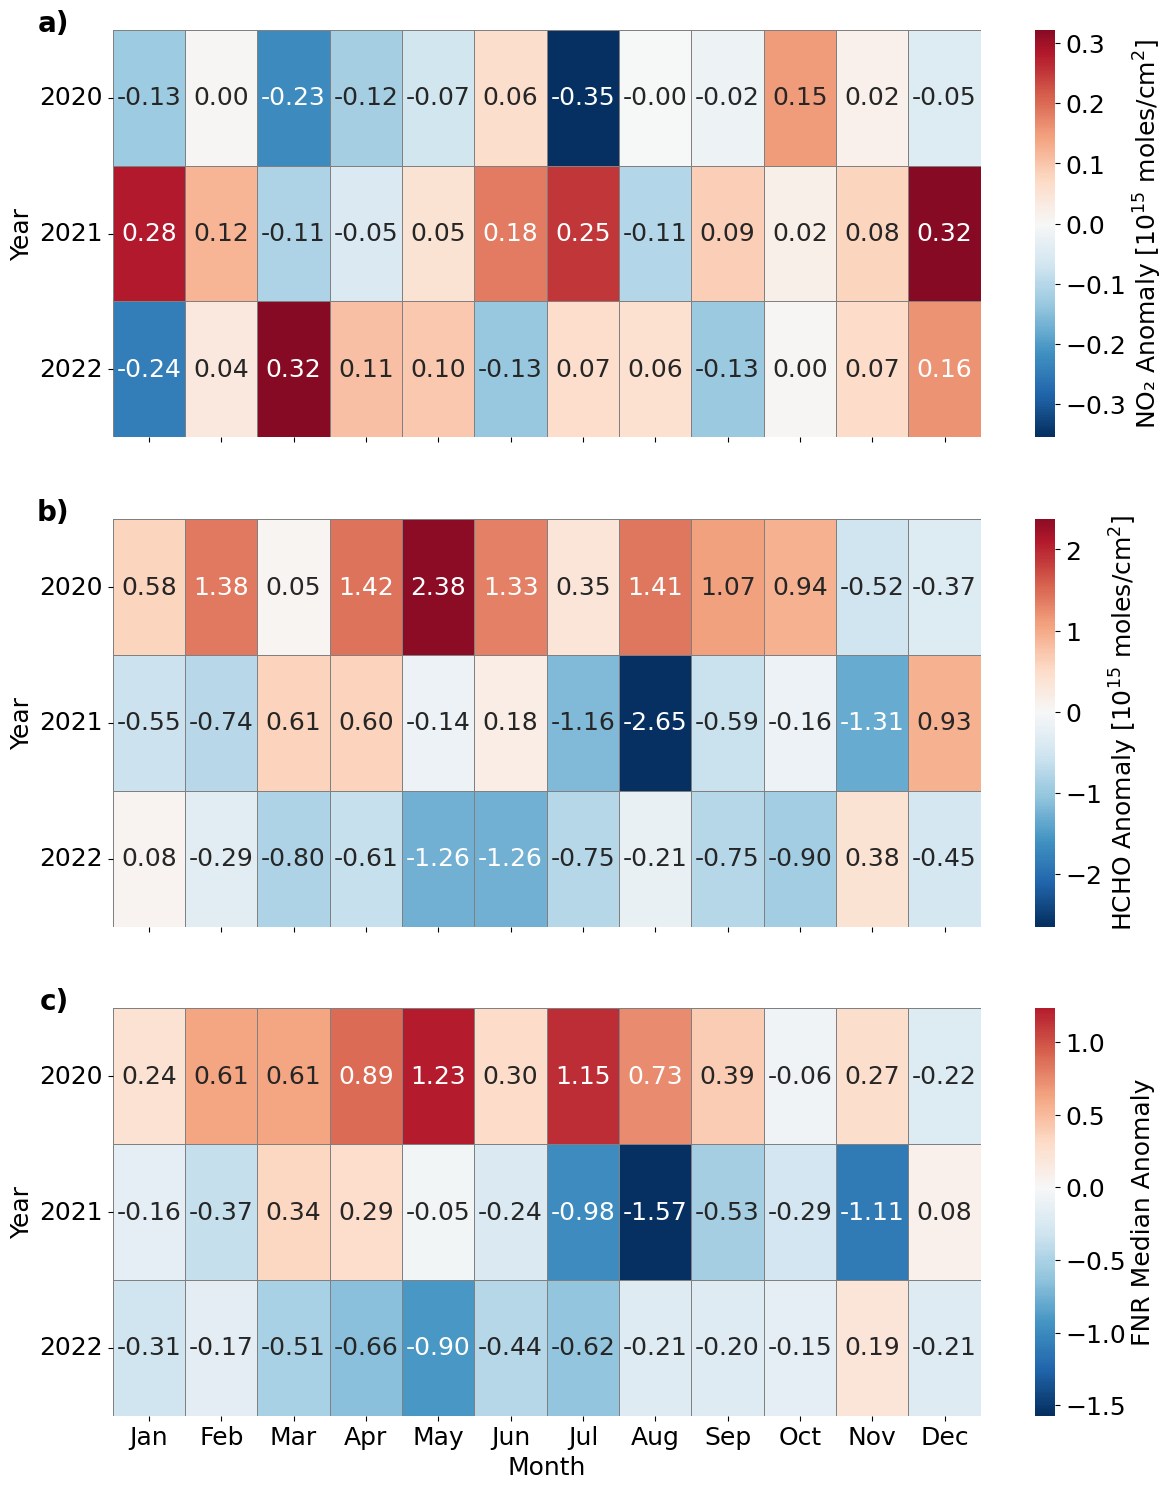

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import calendar

def build_anomaly_matrix(summaries, id):
    records = []
    for key, df in summaries.items():
        if key.startswith(f"{id}_anomaly_"):
            year = int(key.split('_')[2])
            if year in [2019, 2023]:
                continue
            for _, row in df.iterrows():
                records.append({
                    'Year': year,
                    'Month': int(row['Month']),
                    'Anomaly': row['median']
                })

    df_matrix = pd.DataFrame(records)
    pivot = df_matrix.pivot(index='Year', columns='Month', values='Anomaly')
    return pivot

def plot_combined_anomaly_heatmaps(nox_mat, voc_mat, fnr_mat):
    fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharex=True,
                             gridspec_kw={'hspace': 0.20})

    heatmaps = [
        (nox_mat, 'NO\u2082 Anomaly [$10^{15}$ moles/cm$^2$]'),
        (voc_mat, 'HCHO Anomaly [$10^{15}$ moles/cm$^2$]'),
        (fnr_mat, "FNR Median Anomaly")
    ]

    subplot_labels = ['a)', 'b)', 'c)']

    for ax, (data, colorbar_label), label in zip(axes, heatmaps, subplot_labels):
        heatmap = sns.heatmap(data, ax=ax, annot=True, fmt=".2f", cmap="RdBu_r", center=0, annot_kws={"size": 18},
                              cbar_kws={'label': colorbar_label}, linewidths=0.5, linecolor='gray')
        cbar = heatmap.collections[0].colorbar
        cbar.ax.tick_params(labelsize=18)
        cbar.set_label(colorbar_label, fontsize=18)
        ax.set_ylabel("Year", fontsize=18)
        ax.set_xlabel("")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
        ax.tick_params(axis='both', labelsize=18)
        ax.set_xticks(np.arange(12) + 0.5)
        ax.set_xticklabels([calendar.month_abbr[m] for m in range(1, 13)], fontsize=18)

        # Add subplot label in the upper-left corner
        ax.text(-0.05, 1.05, label, transform=ax.transAxes,
                fontsize=20, fontweight='bold', va='top', ha='right')

    axes[-1].set_xlabel("Month", fontsize=18)
    plt.tight_layout()
    plt.show()

# Build matrices (assumes VOC_anomaly_summaries, NOx_anomaly_summaries, and FNR_anomaly_summaries are defined)
voc_matrix = build_anomaly_matrix(VOC_anomaly_summaries, 'VOC')
nox_matrix = build_anomaly_matrix(NOx_anomaly_summaries, 'NOx')
fnr_matrix = build_anomaly_matrix(FNR_anomaly_summaries, 'FNR')

# Plot heatmaps
plot_combined_anomaly_heatmaps(nox_matrix, voc_matrix, fnr_matrix)


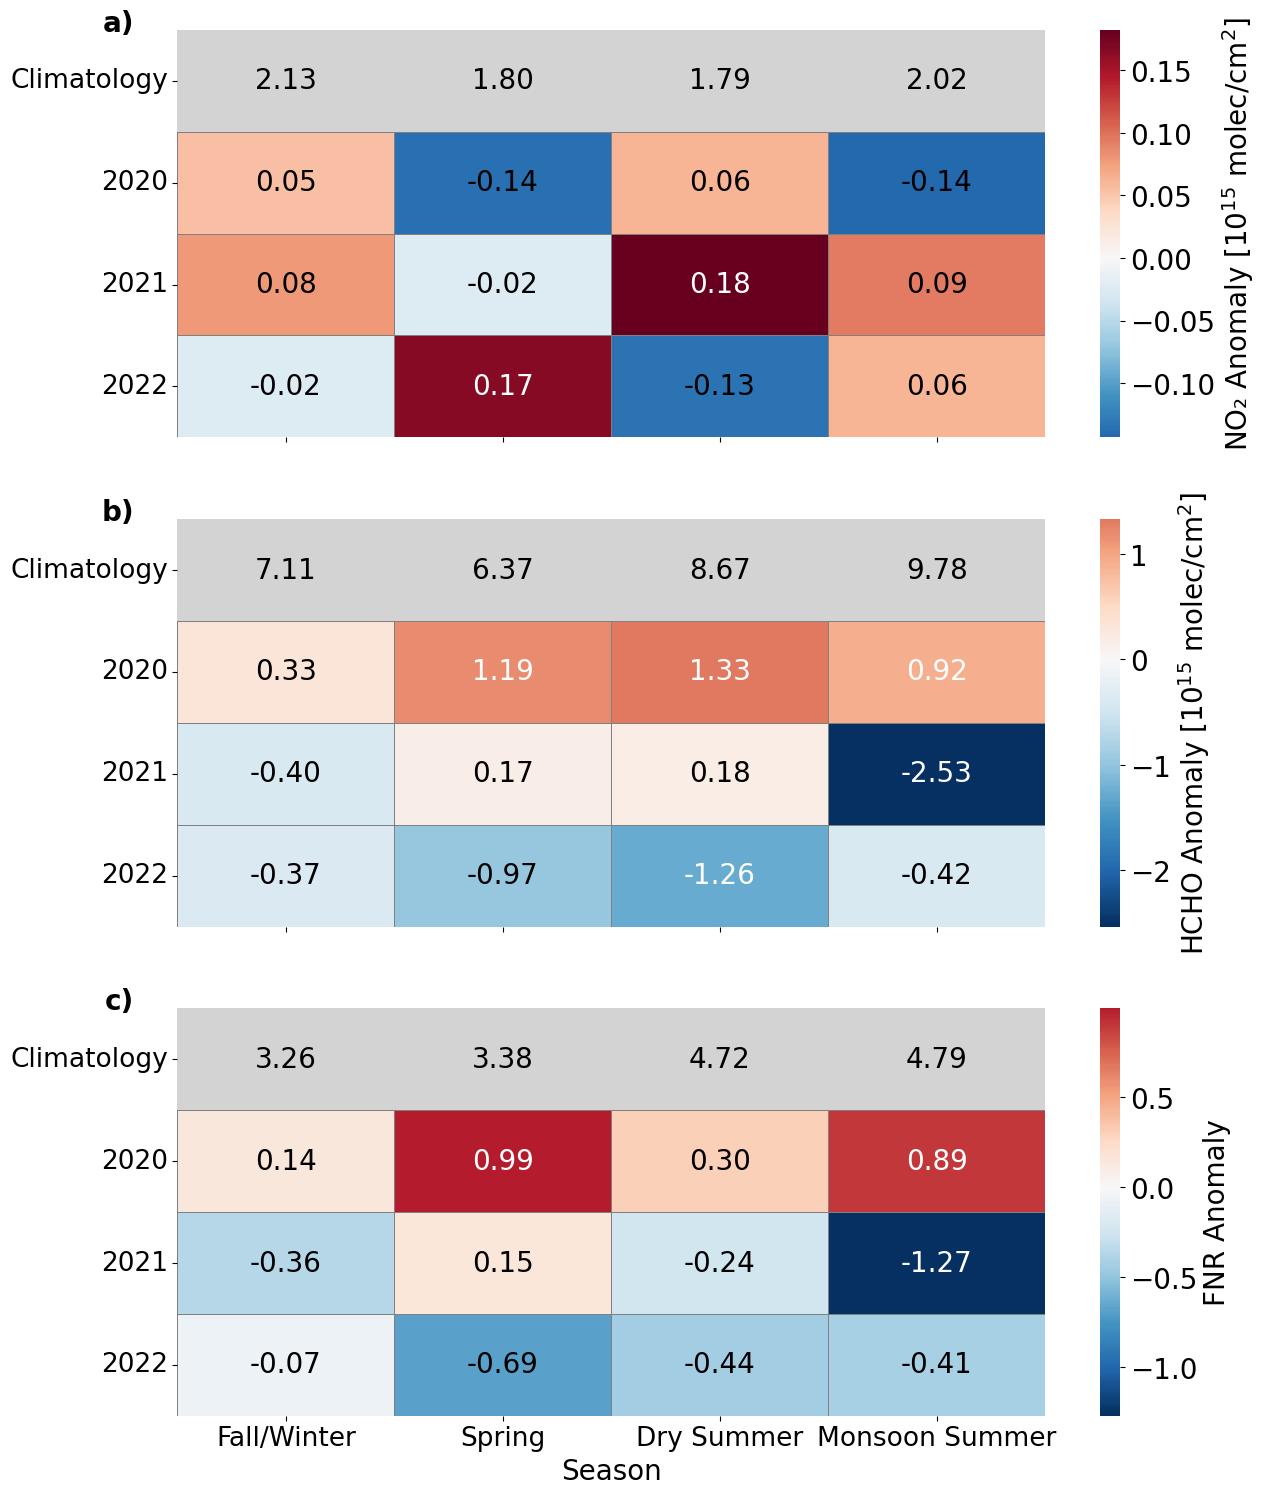

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches
from matplotlib import cm, colors

# Step 1: Add date, year, month, and season
def assign_season(month):
    if month in [9, 10, 11, 12, 1, 2]:
        return "Fall/Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month == 6:
        return "Dry Summer"
    elif month in [7, 8]:
        return "Monsoon Summer"

for df in [combined_HC, combined_Trop]:
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Season'] = df['Month'].apply(assign_season)

# Step 2: Calculate seasonal anomaly vs climatology
def calc_seasonal_climatology_anomaly(df, value_col='Value', id='VOC'):
    summaries = {}
    climatology = df.groupby('Season')[value_col].median().reset_index()
    climatology.rename(columns={value_col: 'Climatology_Median'}, inplace=True)

    for year in [2020, 2021, 2022]:
        if year not in df['Year'].unique():
            continue
        df_year = df[df['Year'] == year].copy()
        merged = pd.merge(df_year, climatology, on='Season')
        merged['anomaly'] = merged[value_col] - merged['Climatology_Median']
        summary = merged.groupby('Season')['anomaly'].median().reset_index()
        summaries[f"{id}_anomaly_{year}_climatology"] = summary

    return summaries, climatology

VOC_anomaly_summaries, VOC_climatology = calc_seasonal_climatology_anomaly(combined_HC, 'Value', 'VOC')
NOx_anomaly_summaries, NOx_climatology = calc_seasonal_climatology_anomaly(combined_Trop, 'Value', 'NOx')

def calc_FNR_seasonal_anomaly(voc_df, nox_df):
    merged = pd.merge(
        voc_df[['Date', 'Value']],
        nox_df[['Date', 'Value']],
        on='Date',
        suffixes=('_VOC', '_NOx')
    )
    merged['FNR_Value'] = merged['Value_VOC'] / merged['Value_NOx']
    merged['Date'] = pd.to_datetime(merged['Date'])
    merged['Year'] = merged['Date'].dt.year
    merged['Month'] = merged['Date'].dt.month
    merged['Season'] = merged['Month'].apply(assign_season)
    return calc_seasonal_climatology_anomaly(merged, 'FNR_Value', 'FNR')

FNR_anomaly_summaries, FNR_climatology = calc_FNR_seasonal_anomaly(combined_HC, combined_Trop)

# Step 3: Build matrix for heatmap
def build_seasonal_anomaly_matrix(summaries, climatology_df, id):
    records = []
    for key, df in summaries.items():
        year = int(key.split('_')[2])
        if year not in [2020, 2021, 2022]:
            continue
        for _, row in df.iterrows():
            records.append({
                'Year': str(year),
                'Season': row['Season'],
                'Anomaly': row['anomaly']
            })

    for _, row in climatology_df.iterrows():
        records.append({
            'Year': 'Climatology',
            'Season': row['Season'],
            'Anomaly': row['Climatology_Median']
        })

    df_matrix = pd.DataFrame(records)
    season_order = ['Fall/Winter', 'Spring', 'Dry Summer', 'Monsoon Summer']
    df_matrix['Season'] = pd.Categorical(df_matrix['Season'], categories=season_order, ordered=True)
    row_order = ['Climatology', '2020', '2021', '2022']
    pivot = df_matrix.pivot(index='Year', columns='Season', values='Anomaly').loc[row_order]
    return pivot

# Step 4: Plot heatmaps
def plot_seasonal_anomaly_heatmaps(nox_mat, voc_mat, fnr_mat):
    fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharex=True, gridspec_kw={'hspace': 0.2})
    heatmaps = [
        (nox_mat, 'NO\u2082 Anomaly [$10^{15}$ molec/cm$^2$]'),
        (voc_mat, 'HCHO Anomaly [$10^{15}$ molec/cm$^2$]'),
        (fnr_mat, 'FNR Anomaly')
    ]
    subplot_labels = ['a)', 'b)', 'c)']

    for idx, (ax, (data, cbar_label), label) in enumerate(zip(axes, heatmaps, subplot_labels)):
        data_masked = data.copy()
        data_masked.loc['Climatology'] = np.nan

        cmap = cm.RdBu_r
        norm = colors.TwoSlopeNorm(vmin=np.nanmin(data_masked.values), vcenter=0, vmax=np.nanmax(data_masked.values))

        sns.heatmap(data_masked, ax=ax, fmt=".2f", cmap=cmap, center=0,
                    annot=False, linewidths=0.5, linecolor='gray',
                    cbar_kws={'label': cbar_label}, mask=data_masked.isnull())

        row_labels = data.index.tolist()
        col_labels = data.columns.tolist()
        clim_idx = row_labels.index("Climatology")

        # Annotate climatology
        for col_idx, season in enumerate(col_labels):
            val = data.loc["Climatology", season]
            rect = patches.Rectangle((col_idx, clim_idx), 1, 1, linewidth=0,
                                     edgecolor='none', facecolor='lightgray', zorder=1)
            ax.add_patch(rect)
            ax.text(col_idx + 0.5, clim_idx + 0.5, f"{val:.2f}",
                    ha='center', va='center', fontsize=20, color='black', zorder=2)

        # Annotate rest
        for i, row in enumerate(data.index):
            if row != "Climatology":
                for j, season in enumerate(data.columns):
                    val = data.loc[row, season]
                    if val < -1.0:
                        text_color = 'white'
                    elif idx == 0 and val > 0.15:
                        text_color = 'white'
                    elif idx != 0 and val > 0.8:
                        text_color = 'white'
                    else:
                        text_color = 'black'
                    ax.text(j + 0.5, i + 0.5, f"{val:.2f}",
                            ha='center', va='center', fontsize=20, color=text_color)

        cbar = ax.collections[0].colorbar
        cbar.ax.tick_params(labelsize=20)
        cbar.set_label(cbar_label, fontsize=20)

        ax.set_ylabel("", fontsize=20)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
        ax.set_xticklabels(data.columns, fontsize=20)
        ax.tick_params(axis='both', labelsize=19)
        ax.set_xlabel("")
        ax.text(-0.05, 1.05, label, transform=ax.transAxes,
                fontsize=20, fontweight='bold', va='top', ha='right')

    axes[-1].set_xlabel("Season", fontsize=20)
    plt.tight_layout()
    plt.show()

# Step 5: Build matrices and plot
voc_matrix = build_seasonal_anomaly_matrix(VOC_anomaly_summaries, VOC_climatology, 'VOC')
nox_matrix = build_seasonal_anomaly_matrix(NOx_anomaly_summaries, NOx_climatology, 'NOx')
fnr_matrix = build_seasonal_anomaly_matrix(FNR_anomaly_summaries, FNR_climatology, 'FNR')

plot_seasonal_anomaly_heatmaps(nox_matrix, voc_matrix, fnr_matrix)


In [16]:
"""import calendar

def build_box_data(summary_df):
    return [
        [row['percentile_25'], row['median'], row['percentile_75']]
        for _, row in summary_df.iterrows()
    ]

def plot_summary_boxplots(nox_sum, voc_sum, fnr_sum):
    nox_21_20 = build_box_data(nox_sum['NOx_anomaly_2021_2020'])
    nox_22_21 = build_box_data(nox_sum['NOx_anomaly_2022_2021'])
    voc_21_20 = build_box_data(voc_sum['VOC_anomaly_2021_2020'])
    voc_22_21 = build_box_data(voc_sum['VOC_anomaly_2022_2021'])
    fnr_21_20 = build_box_data(fnr_sum['FNR_anomaly_2021_2020'])
    fnr_22_21 = build_box_data(fnr_sum['FNR_anomaly_2022_2021'])

    months = [calendar.month_abbr[m] for m in range(1, 13)]

    # Add spacing: use step=3 for better separation
    x_base = np.arange(1, 13) * 3
    pos_1 = x_base - 0.6
    pos_2 = x_base + 0.6
    tick_positions = x_base

    fig, axes = plt.subplots(3, 1, figsize=(20, 18), sharex=True)
    colors = {'2021-2020': 'salmon', '2022-2021': 'lightblue'}

    def draw(ax, data1, data2, ylabel, tag):
        ax.boxplot(
            data1, positions=pos_1, widths=1.0, patch_artist=True, showmeans=True,
            boxprops=dict(facecolor=colors['2021-2020'], color='black'),
            medianprops=dict(color='black', linewidth=2),
            meanprops=dict(marker='^', markerfacecolor='gold', markersize=12)
        )
        ax.boxplot(
            data2, positions=pos_2, widths=1.0, patch_artist=True, showmeans=True,
            boxprops=dict(facecolor=colors['2022-2021'], color='black'),
            medianprops=dict(color='black', linewidth=2),
            meanprops=dict(marker='^', markerfacecolor='gold', markersize=12)
        )
        ax.set_xticks(tick_positions)
        ax.axhline(y=0, color='k', linestyle='--', linewidth=3, alpha=0.5)
        ax.set_xticklabels(months, fontsize=25)
        ax.set_xlim(x_base[0] - 2, x_base[-1] + 2)
        ax.set_ylabel(ylabel, fontsize=24)
        ax.tick_params(axis='y', labelsize=25)
        ax.text(0.01, 0.95, tag, fontsize=25, transform=ax.transAxes, va='top')
        ax.grid(True, linestyle='--', alpha=0.5)

    draw(axes[1], voc_21_20, voc_22_21, 'HCHO Anomaly [$10^{15}$ moles/cm$^2$]', 'b)')
    draw(axes[0], nox_21_20, nox_22_21, 'NO\u2082 Anomaly [$10^{15}$ moles/cm$^2$]', 'a)')
    draw(axes[2], fnr_21_20, fnr_22_21, 'FNR Anomaly', 'c)')

    handles = [
        plt.Line2D([0], [0], color=colors['2021-2020'], lw=10, label='2021-2020'),
        plt.Line2D([0], [0], color=colors['2022-2021'], lw=10, label='2022-2021')
    ]
    axes[0].legend(handles=handles, fontsize=22, loc='lower right')

    plt.tight_layout()
    plt.show()

# Call the function
plot_summary_boxplots(NOx_anomaly_summaries, VOC_anomaly_summaries, FNR_anomaly_summaries)"""


"import calendar\n\ndef build_box_data(summary_df):\n    return [\n        [row['percentile_25'], row['median'], row['percentile_75']]\n        for _, row in summary_df.iterrows()\n    ]\n\ndef plot_summary_boxplots(nox_sum, voc_sum, fnr_sum):\n    nox_21_20 = build_box_data(nox_sum['NOx_anomaly_2021_2020'])\n    nox_22_21 = build_box_data(nox_sum['NOx_anomaly_2022_2021'])\n    voc_21_20 = build_box_data(voc_sum['VOC_anomaly_2021_2020'])\n    voc_22_21 = build_box_data(voc_sum['VOC_anomaly_2022_2021'])\n    fnr_21_20 = build_box_data(fnr_sum['FNR_anomaly_2021_2020'])\n    fnr_22_21 = build_box_data(fnr_sum['FNR_anomaly_2022_2021'])\n\n    months = [calendar.month_abbr[m] for m in range(1, 13)]\n\n    # Add spacing: use step=3 for better separation\n    x_base = np.arange(1, 13) * 3\n    pos_1 = x_base - 0.6\n    pos_2 = x_base + 0.6\n    tick_positions = x_base\n\n    fig, axes = plt.subplots(3, 1, figsize=(20, 18), sharex=True)\n    colors = {'2021-2020': 'salmon', '2022-2021': 'light

KeyError: 'VOC_anomaly_2021_2020'

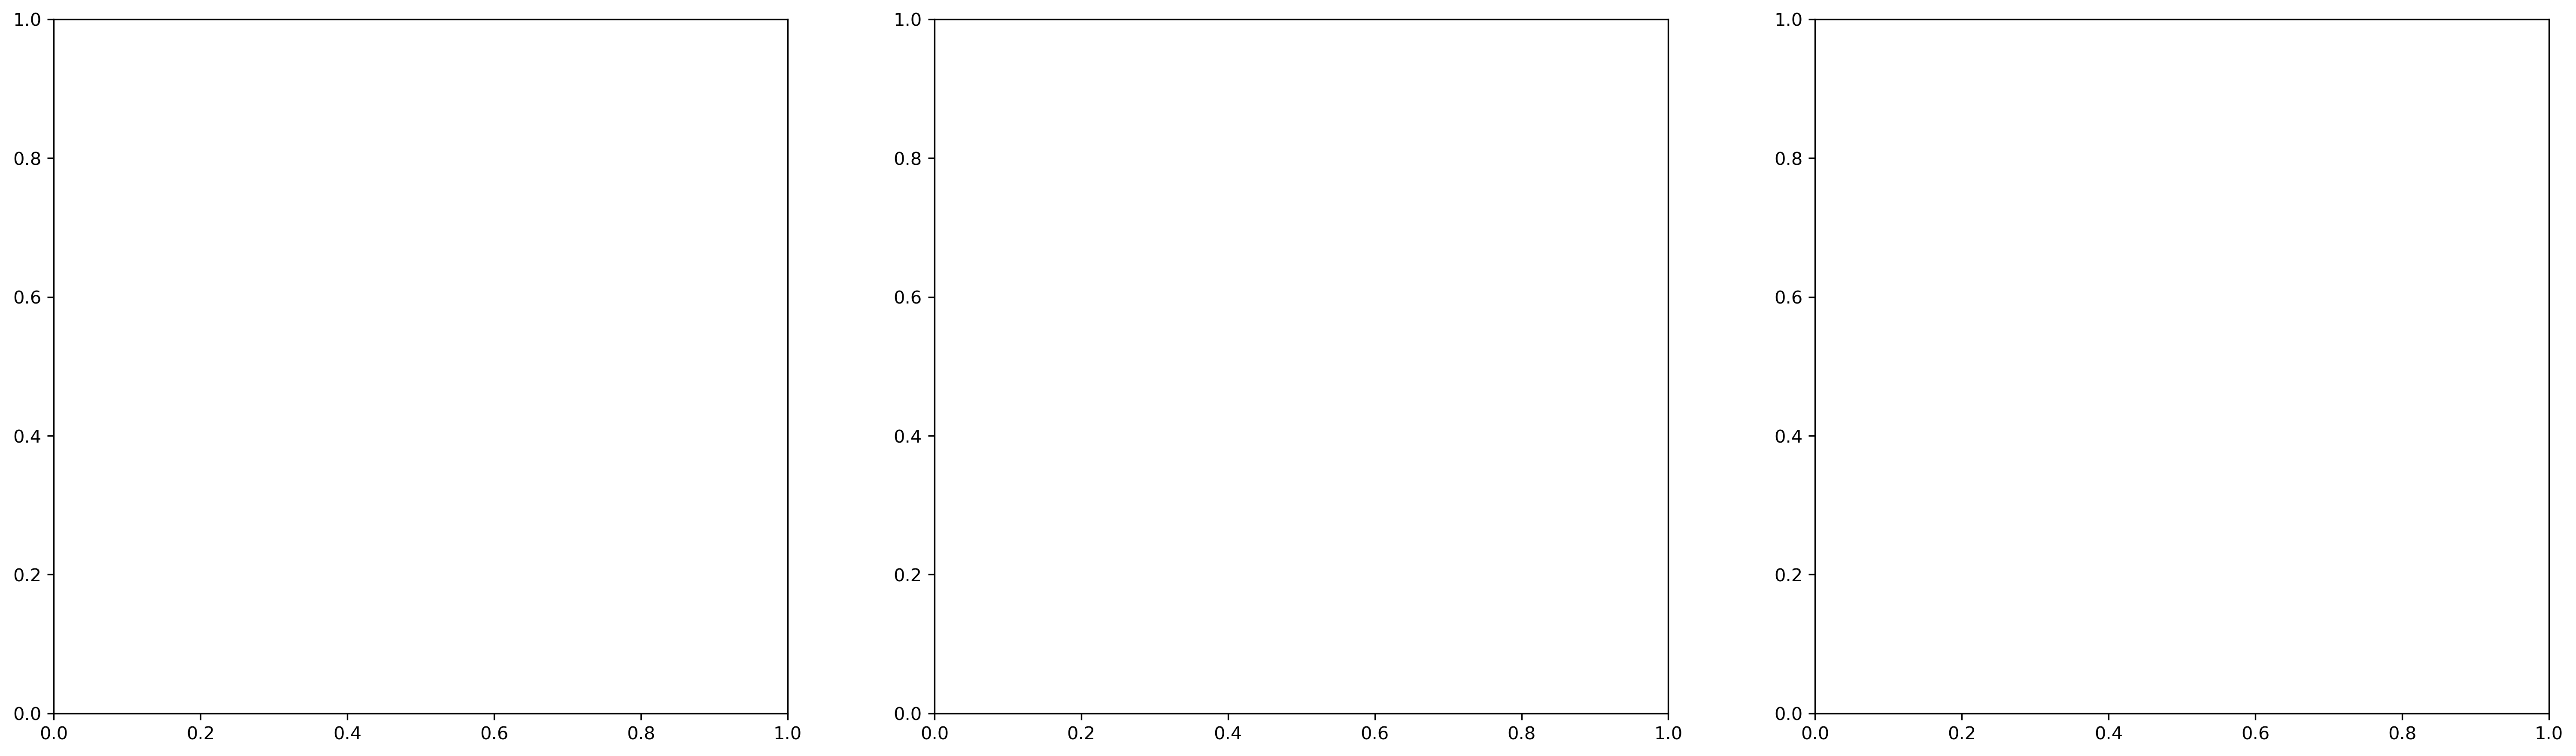

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import calendar

def extract_lines(summary_df):
    """Extract percentiles from summary DataFrame"""
    summary_df = summary_df.sort_values('Month')
    months = [calendar.month_abbr[m] for m in summary_df['Month']]
    median = summary_df['median'].values
    p25 = summary_df['percentile_25'].values
    p75 = summary_df['percentile_75'].values
    return months, median, p25, p75

def plot_summary_lineplots(voc_sum, nox_sum, fnr_sum):
    fig, axes = plt.subplots(1, 3, figsize=(25, 7), dpi=300, sharey=False)

    colors = {'2021-2020': 'red', '2022-2021': 'blue'}
    labels = ['(a)', '(b)', '(c)']
    metrics = [
        ('VOC Anomaly', voc_sum['VOC_anomaly_2021_2020'], voc_sum['VOC_anomaly_2022_2021']),
        ('NOx Anomaly', nox_sum['NOx_anomaly_2021_2020'], nox_sum['NOx_anomaly_2022_2021']),
        ('FNR Anomaly', fnr_sum['FNR_anomaly_2021_2020'], fnr_sum['FNR_anomaly_2022_2021'])
    ]

    for ax, (ylabel, df_21_20, df_22_21), label in zip(axes, metrics, labels):
        months, med1, p25_1, p75_1 = extract_lines(df_21_20)
        _,     med2, p25_2, p75_2 = extract_lines(df_22_21)

        x = np.arange(1, 13)

        ax.plot(x, med1, label='2021-2020', color=colors['2021-2020'], marker='o')
        ax.plot(x, p25_1, linestyle='--', color=colors['2021-2020'], alpha=0.5)
        ax.plot(x, p75_1, linestyle='--', color=colors['2021-2020'], alpha=0.5)

        ax.plot(x, med2, label='2022-2021', color=colors['2022-2021'], marker='o')
        ax.plot(x, p25_2, linestyle='--', color=colors['2022-2021'], alpha=0.5)
        ax.plot(x, p75_2, linestyle='--', color=colors['2022-2021'], alpha=0.5)

        ax.set_xticks(x)
        ax.set_xticklabels(months, fontsize=22, rotation=45)
        ax.set_ylabel(ylabel, fontsize=22)
        ax.tick_params(axis='y', labelsize=22)
        ax.text(0.01, 0.95, label, fontsize=20, transform=ax.transAxes, va='top')
        ax.grid(True, linestyle='--', alpha=0.5)

    axes[0].legend(title='Anomaly Periods', fontsize=14, title_fontsize=16, loc='upper left')

    plt.tight_layout()
    plt.show()

# Call this with your summary dictionaries
plot_summary_lineplots(VOC_anomaly_summaries, NOx_anomaly_summaries, FNR_anomaly_summaries)


In [ ]:
# Create figure with 3 subplots
fig, axs = plt.subplots(1, 3, figsize=(25, 7), sharey=False, dpi=300)

# Subplots for NO₂, VOC, and FNR
plot_data = [
    ("NO\u2082 [$10^{15}$ moles/cm$^2$]", NOx_stats_df),
    ("CH$_{\mathrm{2}}$O [$10^{15}$ moles/cm$^2$]", VOC_stats_df),
    ("FNR", FNR_stats_dff),
]

# Define colors for each period
periods = [
    #('2019', 'blue'),
    ('2020', 'red'),
    ('2021', "blue"),
    ('2022', 'c')
]

# Labels for the subplots
subplot_labels = ['(a)', '(b)', '(c)']

# Loop through each subplot and plot data
for ax, (ylabel, data_source), label in zip(axs, plot_data, subplot_labels):
    for period, color in periods:
        df_period = data_source[data_source['Period'] == period]  # Filter data for the period

        ax.plot(df_period['Month'], df_period['average'], label=period, color=color, marker='o', markersize=6)
        ax.fill_between(df_period['Month'], df_period['percentile_25'], df_period['percentile_75'], alpha=0.05, color=color)

    # Add horizontal dashed lines if applicable (for FNR only)
    if ylabel == "FNR":
        ax.axhline(y=3.2, color='k', linestyle='--', linewidth=3, alpha=1)
        ax.axhline(y=4.2, color='k', linestyle='--', linewidth=3, alpha=1)


        # NOx-Limited (Upward arrow ↑)
        ax.annotate("NO$_{\mathrm{x}}$-Limited", xy=(8, 5.1), fontsize=16, color='k', ha='center')
        ax.annotate("", xy=(8, 5.0), xytext=(8, 4.2), 
                    arrowprops=dict(facecolor='k', arrowstyle="simple", 
                                    connectionstyle="angle3,angleA=0,angleB=90"))

        # Transitional (Double-headed arrow ↑↓)
        ax.annotate("Transitional", xy=(8, 3.5), fontsize=16, color='k', ha='center')
        #ax.annotate("", xy=(6, 3.3), xytext=(6, 3.6), 
        #            arrowprops=dict(facecolor='g', arrowstyle="simple", 
                               #     connectionstyle="angle3,angleA=0,angleB=90"))

        # VOC-Limited (Downward arrow ↓)
        ax.annotate("VOC-Limited", xy=(8, 2.4), fontsize=16, color='k', ha='center')
        ax.annotate("", xy=(8, 2.6), xytext=(8, 3.2), 
                    arrowprops=dict(facecolor='k', arrowstyle="simple", 
                                    connectionstyle="angle3,angleA=0,angleB=-90"))

    # Set y-axis label
    ax.set_ylabel(ylabel, fontsize=20)
    ax.tick_params(axis='y', labelsize=20)

    # Add subplot label in the top-left corner
    ax.text(0.02, 0.95, label, transform=ax.transAxes, fontsize=20, fontweight='bold', va='top', ha='left')

# Common x-axis settings for all subplots
for ax in axs:
    ax.set_xlabel('Month', fontsize=20)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], fontsize=20, rotation=45)

# Add legend to the first subplot
axs[0].legend(title='Periods', fontsize=20, title_fontsize=20, loc='upper center', bbox_to_anchor=(2.75, 1.28), ncol=4)

#plt.tight_layout()
plt.show()


In [ ]:
# Create figure with 3 subplots
fig, axs = plt.subplots(1, 3, figsize=(25, 7), sharey=False, dpi=300)

# Subplots for NO₂, VOC, and FNR
plot_data = [
    ("NO\u2082 [$10^{15}$ moles/cm$^2$]", NOx_stats_df),
    ("CH$_{\mathrm{2}}$O [$10^{15}$ moles/cm$^2$]", VOC_stats_df),
    ("FNR", FNR_stats_dff),
]

# Define colors for each period
periods = [
    ('2020', 'red'),
    ('2021', 'blue'),
    ('2022', 'c')
]

# Labels for the subplots
subplot_labels = ['(a)', '(b)', '(c)']

# Loop through each subplot and plot data
for ax, (ylabel, data_source), label in zip(axs, plot_data, subplot_labels):
    for period, color in periods:
        df_period = data_source[data_source['Period'] == period]

        # Central line (median or average)
        ax.plot(df_period['Month'], df_period['average'], label=period,
                color=color, marker='o', markersize=6)

        # Dashed lines for 25th and 75th percentiles
        ax.plot(df_period['Month'], df_period['percentile_25'], color=color,
                linestyle='--', linewidth=1.5)
        ax.plot(df_period['Month'], df_period['percentile_75'], color=color,
                linestyle='--', linewidth=1.5)

    # Add horizontal dashed lines and annotations (FNR only)
    if ylabel == "FNR":
        ax.axhline(y=3.2, color='k', linestyle='--', linewidth=3, alpha=1)
        ax.axhline(y=4.2, color='k', linestyle='--', linewidth=3, alpha=1)

        # NOx-Limited ↑
        ax.annotate("NO$_{\mathrm{x}}$-Limited", xy=(8, 5.1), fontsize=16, color='k', ha='center')
        ax.annotate("", xy=(8, 5.0), xytext=(8, 4.2),
                    arrowprops=dict(facecolor='k', arrowstyle="simple",
                                    connectionstyle="angle3,angleA=0,angleB=90"))

        # Transitional (↑↓)
        ax.annotate("Transitional", xy=(8, 3.5), fontsize=16, color='k', ha='center')

        # VOC-Limited ↓
        ax.annotate("VOC-Limited", xy=(8, 2.4), fontsize=16, color='k', ha='center')
        ax.annotate("", xy=(8, 2.6), xytext=(8, 3.2),
                    arrowprops=dict(facecolor='k', arrowstyle="simple",
                                    connectionstyle="angle3,angleA=0,angleB=-90"))

    # Y-axis label
    ax.set_ylabel(ylabel, fontsize=20)
    ax.tick_params(axis='y', labelsize=18)

    # Subplot label
    ax.text(0.02, 0.95, label, transform=ax.transAxes,
            fontsize=20, fontweight='bold', va='top', ha='left')

# X-axis formatting
for ax in axs:
    ax.set_xlabel('Month', fontsize=20)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
                       fontsize=18, rotation=45)

# Legend
axs[0].legend(title='Periods', fontsize=18, title_fontsize=18,
              loc='upper center', bbox_to_anchor=(2.75, 1.28), ncol=4)

plt.tight_layout()
plt.show()
